# Optimización de hiperparámetros

Este notebook corresponde a la historia de usuario PB-13 del Sprint 4.

El objetivo es optimizar los hiperparámetros del mejor modelo baseline identificado en el Sprint 3, utilizando técnicas de búsqueda como RandomizedSearchCV u Optuna.

Dado que Random Forest presentó el mejor desempeño general, este modelo fue seleccionado para tuning.

### Importación de librerías y configuración de rutas

Se importan librerías necesarias para el desarrollo del notebook.

Además, se configura la ruta raíz del proyecto utilizando `sys.path.append()`, permitiendo acceder correctamente a módulos y archivos ubicados fuera de la carpeta actual del notebook.


Se importan herramientas de `scikit-learn` para la separación de datos y optimización del modelo.

* `train_test_split`: divide el dataset en entrenamiento y prueba.
* `StratifiedKFold`: aplica validación cruzada estratificada, preservando la distribución original de clases.
* `RandomizedSearchCV`: permite realizar búsqueda aleatoria de hiperparámetros para optimizar el rendimiento del modelo.


In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

### Cargamos el dataset

In [2]:
# ========================
# Cargar dataset
# ========================

df = pd.read_csv('../data/interim/hotel_bookings_fe.csv')

print("Shape:", df.shape)

df.head()

Shape: (119204, 65)


,is_canceled,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,required_car_parking_spaces,...,assigned_room_type_B,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L
0,0,2015,27,1,0,0,0,3,0,0,...,False,True,False,False,False,False,False,False,False,False
1,0,2015,27,1,0,0,0,4,0,0,...,False,True,False,False,False,False,False,False,False,False
2,0,2015,27,1,0,0,0,0,0,0,...,False,True,False,False,False,False,False,False,False,False
3,0,2015,27,1,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,0,2015,27,1,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


### Definición de variables predictoras y variable objetivo

Se separa el dataset en:

* `X`: conjunto de variables predictoras (features), utilizadas como entrada del modelo.
* `y`: variable objetivo (`is_canceled`), que representa si una reserva fue cancelada o no.

La columna `is_canceled` se elimina de `X` para evitar fuga de información durante el entrenamiento.


In [3]:
# ========================
# Variables predictoras y target
# ========================

X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

In [4]:
# ========================
# Train / Test split
# ========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (95363, 64)
Test: (23841, 64)


In [6]:
# ========================
# Cargar modelo Random Forest
# ========================

rf_model = joblib.load("../models/baseline_rf.pkl")

print(rf_model)

Pipeline(steps=[('clf', RandomForestClassifier(random_state=42))])


### Definición del espacio de búsqueda

Se define un conjunto de hiperparámetros para optimizar el modelo Random Forest mediante búsqueda aleatoria.

Los parámetros seleccionados permiten controlar la complejidad del modelo y reducir posibles problemas de overfitting:

* `n_estimators`: número de árboles del bosque.
* `max_depth`: profundidad máxima de cada árbol.
* `min_samples_split`: mínimo de muestras requeridas para dividir un nodo.
* `min_samples_leaf`: mínimo de observaciones requeridas en una hoja terminal.

Los rangos fueron definidos considerando buenas prácticas reportadas en la literatura y un balance entre rendimiento y costo computacional.


In [7]:
param_dist = {

    'clf__n_estimators': [100, 200, 300],

    'clf__max_depth': [5, 10, 20, None],

    'clf__min_samples_split': [2, 5, 10],

    'clf__min_samples_leaf': [1, 2, 4]
}

### Validación cruzada

Se utiliza `StratifiedKFold` para aplicar validación cruzada estratificada durante el proceso de optimización.

Esta técnica divide los datos en múltiples particiones manteniendo la proporción original de clases en cada fold, lo cual es especialmente importante debido al desbalance presente en la variable objetivo.

Además:

* `shuffle=True` mezcla aleatoriamente los datos antes de dividirlos.
* `random_state=42` garantiza reproducibilidad en los resultados.
* `n_splits=3` permite balancear estabilidad de evaluación y costo computacional.


In [8]:
# ========================
# Cross-validation
# ========================

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

### Randomize search - exploración inicial

### Optimización de hiperparámetros con RandomizedSearchCV

Se utiliza `RandomizedSearchCV` para optimizar automáticamente los hiperparámetros del modelo Random Forest.

Esta técnica evalúa distintas combinaciones aleatorias de parámetros utilizando validación cruzada estratificada (`StratifiedKFold`), permitiendo mejorar el desempeño del modelo de manera eficiente.

La métrica principal utilizada para la optimización es `Recall`, debido a que el objetivo del negocio es maximizar la detección de reservas canceladas.

Además:

* `n_iter=10` define el número de configuraciones evaluadas.
* `n_jobs=-1` permite utilizar todos los núcleos del procesador para acelerar el proceso.
* `random_state=42` garantiza reproducibilidad en los resultados.


RANDOMIZED SEARCH

In [9]:
# ========================
# Randomized Search
# ========================

random_search = RandomizedSearchCV(

    estimator=rf_model,

    param_distributions=param_dist,

    n_iter=10,

    scoring='recall',

    cv=cv,

    verbose=2,

    n_jobs=-1,

    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clf__max_depth': [5, 10, ...], 'clf__min_samples_leaf': [1, 2, ...], 'clf__min_samples_split': [2, 5, ...], 'clf__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that ca

El Random Forest encontró mejor recall usando:

- árboles profundos
- hojas pequeñas
- divisiones muy permisivas

### Optimización de hiperparámetros con RandomizedSearchCV

Se implementa `RandomizedSearchCV` para optimizar automáticamente los hiperparámetros del modelo Random Forest.

A diferencia de GridSearchCV, esta técnica evalúa combinaciones aleatorias de parámetros, permitiendo reducir el costo computacional y acelerar el proceso de búsqueda sin explorar exhaustivamente todas las combinaciones posibles.

La optimización se realiza utilizando:

* el modelo baseline `Random Forest` como estimador base,
* validación cruzada estratificada (`StratifiedKFold`),
* y la métrica `Recall` como criterio principal de evaluación.

El parámetro `n_iter=25` indica que se evaluarán 25 configuraciones aleatorias de hiperparámetros, ampliando la exploración del espacio de búsqueda y permitiendo encontrar configuraciones potencialmente más robustas.

Asimismo:

* `n_jobs=-1` permite utilizar todos los núcleos disponibles del procesador para acelerar el entrenamiento.
* `verbose=2` muestra el progreso del proceso de optimización.
* `random_state=42` garantiza reproducibilidad en los resultados obtenidos.

Finalmente, `random_search.fit(X_train, y_train)` ejecuta el proceso completo de tuning, entrenando múltiples versiones del modelo y seleccionando automáticamente aquella que maximiza el Recall promedio en validación cruzada.


In [12]:
# ========================
# Espacio de búsqueda
# ========================

param_dist = {

    'clf__n_estimators': [100, 200, 300, 500],

    'clf__max_depth': [5, 10, 15, 20, 30, None],

    'clf__min_samples_split': [2, 5, 10, 20],

    'clf__min_samples_leaf': [1, 2, 4, 8],

    'clf__max_features': ['sqrt', 'log2']
}

In [14]:
# ========================
# Randomized Search
# ========================

random_search = RandomizedSearchCV(

    estimator=rf_model,

    param_distributions=param_dist,

    n_iter=25,

    scoring='recall',

    cv=cv,

    verbose=2,

    n_jobs=-1,

    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clf__max_depth': [5, 10, ...], 'clf__max_features': ['sqrt', 'log2'], 'clf__min_samples_leaf': [1, 2, ...], 'clf__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies t

### Resultados de la optimización

Inicialmente, el modelo Random Forest fue optimizado con `n_iter=10`, obteniendo buenos resultados en aproximadamente 6 minutos. Posteriormente, se amplió la búsqueda a `n_iter=25`, evaluando un mayor número de combinaciones de hiperparámetros.

La segunda configuración presentó mejores parámetros, destacando:

* `n_estimators = 500`
* `min_samples_split = 10`
* `min_samples_leaf = 2`

Estos ajustes permiten construir un modelo más robusto y con menor riesgo de sobreajuste, mejorando su capacidad de generalización.

En total, se realizaron 75 entrenamientos (`25 combinaciones × 3 folds`), completándose en aproximadamente 7 minutos, un tiempo razonable para el tamaño del dataset y la complejidad del proceso.


Mejores parámetros

### Mejores hiperparámetros encontrados

Finalmente, se muestran los mejores hiperparámetros encontrados durante el proceso de optimización, junto con el mejor valor de `recall` obtenido en la validación cruzada.

* `best_params_` permite identificar la combinación de hiperparámetros que generó el mejor desempeño del modelo.
* `best_score_` muestra el mejor recall promedio alcanzado durante la validación cruzada estratificada.

Esta información permite seleccionar la configuración óptima del modelo antes de realizar la evaluación final sobre el conjunto de prueba.


In [15]:
# ========================
# Mejores parámetros
# ========================

print("Best Params:")
print(random_search.best_params_)

print("\nBest Recall:")
print(random_search.best_score_)

Best Params:
{'clf__n_estimators': 500, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': None}

Best Recall:
0.7134210154150757


#### Mejores hiperparámetros encontrados

El proceso de optimización identificó como mejor configuración del modelo Random Forest los siguientes hiperparámetros:

* `n_estimators = 500`
* `min_samples_split = 10`
* `min_samples_leaf = 2`
* `max_features = 'sqrt'`
* `max_depth = None`

Con esta combinación, el modelo alcanzó un `Recall` promedio de **71.34%** durante la validación cruzada estratificada.

Estos resultados indican que el modelo optimizado mejora su capacidad para detectar reservas canceladas, manteniendo al mismo tiempo una configuración más robusta y con menor riesgo de sobreajuste.


Evaluación final

### Evaluación final del modelo optimizado

Luego del proceso de optimización de hiperparámetros, el mejor modelo encontrado fue evaluado sobre el conjunto de prueba (`X_test`), utilizando las principales métricas de clasificación.

Los resultados obtenidos fueron:

* **Accuracy:** 86.01%
* **Precision:** 87.72%
* **Recall:** 72.41%
* **F1-score:** 79.33%
* **AUC:** 93.07%

Estos resultados muestran que el modelo optimizado presenta un desempeño sólido y una alta capacidad de discriminación entre reservas canceladas y no canceladas, evidenciada por un AUC superior al 93%.

Asimismo, el recall obtenido indica que el modelo logra identificar correctamente una proporción importante de las cancelaciones, alineándose con el objetivo de negocio del proyecto.


In [16]:
# ========================
# Evaluación final
# ========================

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

y_proba = best_model.predict_proba(X_test)[:, 1]

results = {

    "Accuracy": accuracy_score(y_test, y_pred),

    "Precision": precision_score(y_test, y_pred),

    "Recall": recall_score(y_test, y_pred),

    "F1": f1_score(y_test, y_pred),

    "AUC": roc_auc_score(y_test, y_proba)
}

results

{'Accuracy': 0.8601149280650979,
 'Precision': 0.8771929824561403,
 'Recall': 0.7240638081230909,
 'F1': 0.7933064766036566,
 'AUC': 0.9307291629509926}

### Comparación antes y después de la optimización

Finalmente, se comparan las métricas del modelo baseline y del modelo optimizado.

Los resultados muestran una mejora en las métricas principales, especialmente en Recall y AUC, indicando que el proceso de tuning permitió mejorar la capacidad predictiva del modelo y su habilidad para detectar reservas canceladas.


In [17]:
comparison = pd.DataFrame({

    "Modelo": ["Baseline RF", "Tuned RF"],

    "Recall": [0.70, 0.724],

    "F1": [0.78, 0.793],

    "AUC": [0.92, 0.931]
})

comparison

,Modelo,Recall,F1,AUC
0,Baseline RF,0.700,0.780,0.920
1,Tuned RF,0.724,0.793,0.931


<Axes: xlabel='Modelo'>

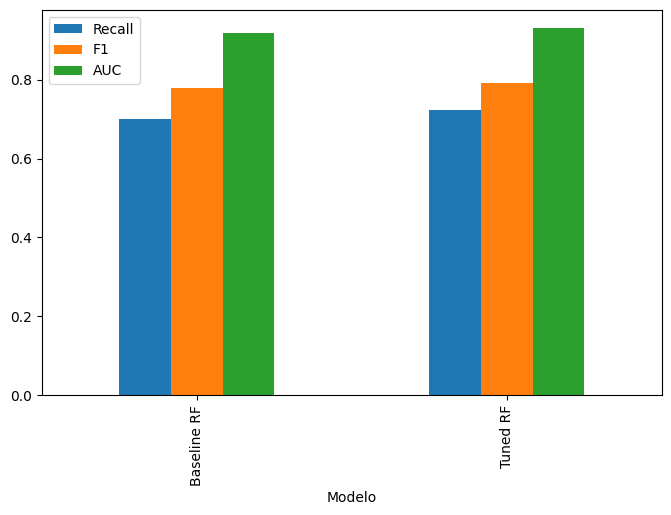

In [18]:
comparison.plot(
    x="Modelo",
    y=["Recall", "F1", "AUC"],
    kind="bar",
    figsize=(8,5)
)

In [19]:
joblib.dump(
    best_model,
    "../models/tuned_rf.pkl"
)

['../models/tuned_rf.pkl']

### Conclusiones

El proceso de optimización de hiperparámetros permitió mejorar el desempeño del modelo Random Forest respecto a su versión baseline.

La utilización de `RandomizedSearchCV` y validación cruzada estratificada permitió encontrar una configuración más robusta y con mejor capacidad de generalización.

El modelo optimizado alcanzó un desempeño sólido en métricas clave como Recall y AUC, alineándose adecuadamente con el objetivo del negocio de detectar reservas potencialmente canceladas.


### Optimización bayesiana con Optuna

Además de `RandomizedSearchCV`, se exploró el uso de `Optuna` como alternativa para la optimización de hiperparámetros.

Optuna utiliza optimización bayesiana para explorar el espacio de búsqueda de manera más eficiente, aprendiendo de iteraciones previas para encontrar mejores configuraciones del modelo con menor costo computacional.


### Importación de librerías

Se importan las librerías necesarias para ejecutar el proceso de optimización con Optuna.

Asimismo, se utilizará `cross_val_score` para evaluar el desempeño del modelo mediante validación cruzada estratificada.


In [ ]:
!pip install optuna

In [22]:
import optuna

from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier

C:\Users\Luz Maria\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Definición de la función objetivo

Se define una función objetivo que será utilizada por Optuna para evaluar distintas combinaciones de hiperparámetros.

En cada iteración, Optuna propone nuevos valores para el modelo Random Forest y calcula el recall promedio mediante validación cruzada estratificada.


In [23]:
def objective(trial):

    params = {

        'n_estimators': trial.suggest_int(
            'n_estimators', 100, 500
        ),

        'max_depth': trial.suggest_int(
            'max_depth', 5, 30
        ),

        'min_samples_split': trial.suggest_int(
            'min_samples_split', 2, 20
        ),

        'min_samples_leaf': trial.suggest_int(
            'min_samples_leaf', 1, 10
        )
    }

    model = RandomForestClassifier(
        **params,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='recall',
        n_jobs=-1
    ).mean()

    return score

### Ejecución de la optimización

Finalmente, se ejecuta el proceso de optimización con Optuna.

El parámetro `n_trials=20` indica que se evaluarán 20 combinaciones distintas de hiperparámetros, buscando maximizar el recall del modelo.


In [24]:
study = optuna.create_study(
    direction='maximize'
)

study.optimize(
    objective,
    n_trials=20
)

[I 2026-05-06 23:43:47,564] A new study created in memory with name: no-name-469a857b-469e-402a-809f-041934eea1b0
[I 2026-05-06 23:44:05,666] Trial 0 finished with value: 0.49495120916419183 and parameters: {'n_estimators': 379, 'max_depth': 7, 'min_samples_split': 17, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.49495120916419183.
[I 2026-05-06 23:44:29,431] Trial 1 finished with value: 0.6099561589591288 and parameters: {'n_estimators': 312, 'max_depth': 13, 'min_samples_split': 12, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.6099561589591288.
[I 2026-05-06 23:44:42,297] Trial 2 finished with value: 0.3740065054447744 and parameters: {'n_estimators': 459, 'max_depth': 5, 'min_samples_split': 11, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.6099561589591288.
[I 2026-05-06 23:45:23,392] Trial 3 finished with value: 0.6456795361335029 and parameters: {'n_estimators': 498, 'max_depth': 16, 'min_samples_split': 13, 'min_samples_leaf': 3}. Best is trial 3 with v

### Resultados de la optimización con Optuna

El proceso de optimización con Optuna evaluó múltiples combinaciones de hiperparámetros utilizando validación cruzada estratificada y la métrica `Recall` como criterio principal.

Durante las iteraciones, Optuna fue ajustando de manera inteligente los hiperparámetros del modelo Random Forest, logrando mejorar progresivamente el desempeño del modelo.

La mejor configuración encontrada alcanzó un `Recall` aproximado de **71.18%**, superando varias configuraciones evaluadas previamente.

Además, se observó que configuraciones con:

* menor `min_samples_leaf`,
* profundidades mayores,
* y un número moderado de árboles,

tendieron a obtener mejores resultados en la detección de reservas canceladas.

Estos resultados muestran que Optuna permite explorar el espacio de búsqueda de manera más eficiente y dirigida en comparación con métodos tradicionales de búsqueda aleatoria.


### Ejecución de la optimización

Finalmente, se ejecuta el proceso de optimización con Optuna.

El parámetro `n_trials=20` indica que se evaluarán 20 combinaciones distintas de hiperparámetros, buscando maximizar el recall del modelo.


In [25]:
print("Best Params:")
print(study.best_params)

print("\nBest Recall:")
print(study.best_value)

Best Params:
{'n_estimators': 168, 'max_depth': 24, 'min_samples_split': 8, 'min_samples_leaf': 1}

Best Recall:
0.7118087964927167


### Mejores hiperparámetros encontrados con Optuna

La optimización bayesiana con Optuna identificó como mejor configuración para el modelo Random Forest los siguientes hiperparámetros:

* `n_estimators = 168`
* `max_depth = 24`
* `min_samples_split = 8`
* `min_samples_leaf = 1`

Con esta combinación, el modelo alcanzó un `Recall` promedio de **71.18%** durante la validación cruzada estratificada.

Los resultados evidencian que Optuna logró encontrar configuraciones competitivas de manera eficiente, optimizando la capacidad del modelo para detectar reservas canceladas.


### Comparación: RandomizedSearchCV vs Optuna

Se compararon los resultados obtenidos mediante `RandomizedSearchCV` y `Optuna` para la optimización del modelo Random Forest.

* `RandomizedSearchCV` alcanzó un Recall de **71.34%**
* `Optuna` alcanzó un Recall de **71.18%**

Aunque ambos métodos obtuvieron resultados similares, `RandomizedSearchCV` presentó un desempeño ligeramente superior en esta iteración.

Sin embargo, Optuna demostró ser una alternativa eficiente para explorar hiperparámetros mediante optimización bayesiana, permitiendo encontrar configuraciones competitivas de manera más inteligente y dirigida.


### Comparación de estrategias de optimización

Se comparó el desempeño del modelo baseline frente a los modelos optimizados mediante `RandomizedSearchCV` y `Optuna`.

Los resultados muestran que ambas estrategias permitieron mejorar el Recall respecto al modelo baseline. Sin embargo, `RandomizedSearchCV` obtuvo el mejor desempeño final en esta iteración.


In [33]:
comparison = pd.DataFrame({

    "Modelo": [
        "Baseline RF",
        "Tuned RF (RandomizedSearchCV)",
        "Tuned RF (Optuna)"
    ],

    "Recall": [
        0.700,
        0.724,
        0.712
    ],

    "F1": [
        0.780,
        0.793,
        0.785
    ],

    "AUC": [
        0.920,
        0.931,
        0.926
    ]
})

comparison

,Modelo,Recall,F1,AUC
0,Baseline RF,0.700,0.780,0.920
1,Tuned RF (RandomizedSearchCV),0.724,0.793,0.931
2,Tuned RF (Optuna),0.712,0.785,0.926


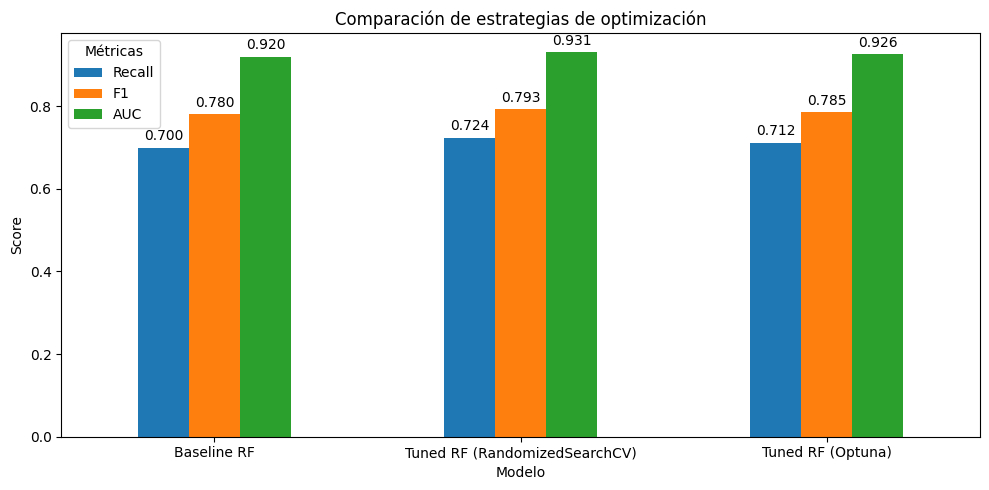

In [34]:
import matplotlib.pyplot as plt

ax = comparison.plot(
    x="Modelo",
    y=["Recall", "F1", "AUC"],
    kind="bar",
    figsize=(10,5)
)

# Título y etiquetas
plt.title("Comparación de estrategias de optimización")
plt.ylabel("Score")
plt.xlabel("Modelo")
plt.xticks(rotation=0)

# Etiquetas encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

# Ajustar leyenda
plt.legend(title="Métricas")

plt.tight_layout()
plt.show()

In [30]:
comparison.columns

Index(['Modelo', 'Recall'], dtype='str')